# Session 22 — End-to-End Supervised Classification Pipeline: Data Cleaning, Outlier Rectification (IQR), Feature Encoding, Model Benchmarking, and Resampled Hyperparameter Optimization
---

### **Overview & Learning Objectives**
In commercial data science projects, building a high-performing classification model requires an end-to-end disciplined workflow: from raw ingestion and exploratory data analysis (EDA), through statistical data cleaning and encoding, to class balancing and hyperparameter optimization.

In this session, we analyze the official **Kaggle Zomato Restaurants Dataset** ($N=9,551$ restaurants) to predict whether an establishment achieves elite rating status ($\text{Rating} > 4.0$).

We systematically address:
1. **Raw Dataset Ingestion & Structural EDA**: Loading multi-country restaurant records, mapping column semantics, and computing summary statistics via `.info()` and `.describe()`.
2. **Missing Value Imputation & IQR Outlier Rectification**: Identifying unrated restaurants ($\text{Rating} = 0$), imputing missing costs, and applying the **Interquartile Range (IQR)** rule to detect and cap extreme pricing outliers:
   $$\text{IQR} = Q_3 - Q_1, \quad \text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$
3. **Feature Preprocessing Pipeline (Encoding & Scaling)**: Engineering categorical variables (`cuisine`, `location`) using frequency grouping and `LabelEncoder` / `OneHotEncoder`, scaling continuous features with `StandardScaler`, and formally preventing target leakage.
4. **Model Comparison & ROC-AUC Benchmarking**: Training **Logistic Regression** (linear decision boundary) versus **Random Forest** (non-linear ensemble), plotting receiver operating characteristic curves, and evaluating discriminatory power via **ROC-AUC**.
5. **Imbalanced Learning via SMOTE & Exhaustive Grid Search**: Applying Synthetic Minority Over-sampling Technique (`imblearn.over_sampling.SMOTE`) to balance high-rated restaurants ($\approx 16.5\%$ minority rate) in the training split, and optimizing `n_estimators` and `max_depth` using `GridSearchCV(scoring='roc_auc')`.

| Question | Core Task | Dataset / Scope | Primary Tools / Classes | Key Output / Metric |
| :--- | :--- | :--- | :--- | :--- |
| **Question 1** | Dataset Ingestion & EDA | Zomato Kaggle Benchmark ($N=9,551$) | `pandas.read_csv`, `.info()`, `.describe()` | 5-Row Sample & Distribution Tables |
| **Question 2** | Data Cleaning & Outliers | `cost` and `rating` Attributes | Interquartile Range (IQR), Capping | Boxplot Visualizations (Before vs After) |
| **Question 3** | Encoding & Feature Scaling | `cuisine`, `location`, `cost`, `rating` | `LabelEncoder`, `StandardScaler` | Preprocessed Feature Matrix & Leakage Analysis |
| **Question 4** | Supervised Model Evaluation | 80/20 Stratified Partition | `LogisticRegression`, `RandomForestClassifier` | ROC-AUC Comparison & Dual ROC Curve Plot |
| **Question 5** | SMOTE & Hyperparameter Tuning | Resampled Training Fold | `SMOTE`, `GridSearchCV` (`n_estimators`, `max_depth`) | Optimal Hyperparameters & Best Test ROC-AUC |


In [1]:
# Environment Setup, Reproducibility Seed, and Package Configurations
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Backward-compatibility shims for imbalanced-learn on newer scikit-learn builds
from sklearn.ensemble import AdaBoostClassifier
_orig_init = AdaBoostClassifier.__init__
def _patched_adaboost_init(self, *args, **kwargs):
    kwargs.pop('algorithm', None)
    return _orig_init(self, *args, **kwargs)
AdaBoostClassifier.__init__ = _patched_adaboost_init

import sklearn.utils.validation
if not hasattr(sklearn.utils.validation, '_is_pandas_df'):
    sklearn.utils.validation._is_pandas_df = lambda X: hasattr(X, 'dtypes') and hasattr(X, 'iloc')

from imblearn.over_sampling import SMOTE

# Plotting configuration
mpl.rcParams['font.enable_last_resort'] = False
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Python Version       : {sys.version.split()[0]}")
print(f"Pandas Version       : {pd.__version__}")
print(f"NumPy Version        : {np.__version__}")
import sklearn; print(f"Scikit-Learn Version : {sklearn.__version__}")
import imblearn; print(f"Imbalanced-Learn     : {imblearn.__version__}")
print("All machine learning, preprocessing, and resampling libraries loaded successfully.")


In C:\Users\LENOVO\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In C:\Users\LENOVO\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In C:\Users\LENOVO\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


Python Version       : 3.13.9
Pandas Version       : 2.3.3
NumPy Version        : 2.3.5
Scikit-Learn Version : 1.9.0
Imbalanced-Learn     : 0.14.0
All machine learning, preprocessing, and resampling libraries loaded successfully.


---
## Question 1
**Download the Zomato Restaurants Kaggle dataset, load it into a pandas DataFrame, and display the first 5 rows along with `info()` and `describe()` output.**

---

### **1. Dataset Overview & Ingestion**
The **Zomato Restaurants Kaggle Dataset** contains worldwide dining information collected via the Zomato API, spanning over $9,500$ establishments across multiple countries.
- Source: Kaggle Zomato Restaurant Data.
- Core attributes: Restaurant Name, City/Location, Cuisines, Average Cost for two, Aggregate Rating, Votes, Table Booking, and Online Delivery flags.


In [2]:
# 1. Ingest Zomato Dataset and Inspect Schema
csv_zomato = "zomato.csv"

if not os.path.exists(csv_zomato):
    import urllib.request
    print("Downloading Zomato dataset from public repository...")
    url = "https://raw.githubusercontent.com/anishmahapatra/Zomato-Data-Visualization/main/data/zomato.csv"
    urllib.request.urlretrieve(url, csv_zomato)

df_raw = pd.read_csv(csv_zomato, encoding='latin-1')

# Standardize key column names for clear, clean reference
df = df_raw.rename(columns={
    'Restaurant Name': 'restaurant_name',
    'City': 'location',
    'Cuisines': 'cuisine',
    'Average Cost for two': 'cost',
    'Aggregate rating': 'rating',
    'Votes': 'votes',
    'Price range': 'price_range',
    'Has Table booking': 'has_table_booking',
    'Has Online delivery': 'has_online_delivery'
})

print("=== First 5 Rows of Zomato Restaurants Dataset ===")
print(df[['restaurant_name', 'location', 'cuisine', 'cost', 'rating', 'votes', 'price_range']].head(5).to_string(index=False))


=== First 5 Rows of Zomato Restaurants Dataset ===
       restaurant_name         location                          cuisine  cost  rating  votes  price_range
      Le Petit Souffle      Makati City       French, Japanese, Desserts  1100     4.8    314            3
      Izakaya Kikufuji      Makati City                         Japanese  1200     4.5    591            3
Heat - Edsa Shangri-La Mandaluyong City Seafood, Asian, Filipino, Indian  4000     4.4    270            4
                  Ooma Mandaluyong City                  Japanese, Sushi  1500     4.9    365            4
           Sambo Kojin Mandaluyong City                 Japanese, Korean  1500     4.8    229            4


In [3]:
# 2. DataFrame Structural Overview: info() and Summary Statistics: describe()
print("=== Zomato Dataset info() Output ===")
df.info()

print("\n=== Zomato Numerical Features describe() Output ===")
print(df[['cost', 'rating', 'votes', 'price_range']].describe().round(2).to_string())


=== Zomato Dataset info() Output ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   restaurant_name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   location              9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   cuisine               9542 non-null   object 
 10  cost                  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  has_table_booking     9551 non-null   object 
 13  has_online_delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null

---
## Question 2
**Check the Zomato dataset for missing values and outliers in the `'cost'` and `'rating'` columns, and handle them appropriately using pandas and numpy.**  
*Hint: For outliers, try using the IQR method or visualize with a boxplot.*

---

### **1. Theoretical Foundations: Outlier Detection via Interquartile Range (IQR)**
An outlier is an observation that lies an abnormal distance from other values in a random sample. The **Interquartile Range (IQR)** is a robust, non-parametric dispersion statistic immune to extreme values:
$$\text{IQR} = Q_3 - Q_1$$
Where:
- $Q_1$ is the first quartile ($25^{\text{th}}$ percentile).
- $Q_3$ is the third quartile ($75^{\text{th}}$ percentile).

#### **Tukey's Fences:**
$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}$$
$$\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$

Observations exceeding the upper bound ($\text{cost} > \text{Upper Bound}$) represent luxury dining or currency anomalies (e.g. Indonesian Rupiah or Filipino Peso). Rather than dropping them and losing valuable records, we apply **Winsorization / Capping** at the upper threshold.

#### **Data Cleaning Decisions:**
1. **Missing Values**:
   - `cost`: Missing or zero costs are imputed using the median cost.
   - `cuisine`: Missing entries are imputed with `'Unknown'`.
2. **Unrated Restaurants**:
   - In Zomato records, $2,148$ restaurants have $\text{Rating} = 0.0$ (representing unrated new listings rather than genuinely zero-rated dining). These unrated records are filtered out to ensure a valid supervised ground truth.


In [4]:
# 1. Missing Value and Zero-Rating Inspection
print("=== Missing Values Breakdown ===")
missing_summary = df[['cost', 'rating', 'cuisine', 'location']].isnull().sum()
print(missing_summary)

zero_ratings = (df['rating'] == 0.0).sum()
zero_costs = (df['cost'] == 0).sum()
print(f"\nUnrated Establishments (Rating == 0.0) : {zero_ratings:,} ({zero_ratings/len(df)*100:.2f}%)")
print(f"Zero-Cost Establishments (Cost == 0)    : {zero_costs:,}")

# Clean dataset: Focus on rated establishments and impute missing cuisines/costs
df_clean = df[df['rating'] > 0.0].copy()
df_clean['cuisine'] = df_clean['cuisine'].fillna('Unknown')
cost_median = df_clean[df_clean['cost'] > 0]['cost'].median()
df_clean['cost'] = df_clean['cost'].replace(0, cost_median).fillna(cost_median)

print(f"\nActive Cleaned Sample Size: {len(df_clean):,} rated restaurants")


=== Missing Values Breakdown ===


cost        0
rating      0
cuisine     9
location    0
dtype: int64

Unrated Establishments (Rating == 0.0) : 2,148 (22.49%)
Zero-Cost Establishments (Cost == 0)    : 18

Active Cleaned Sample Size: 7,403 rated restaurants


In [5]:
# 2. IQR Outlier Detection and Capping on 'cost' and 'rating'
# Outlier analysis for 'cost'
Q1_cost = df_clean['cost'].quantile(0.25)
Q3_cost = df_clean['cost'].quantile(0.75)
IQR_cost = Q3_cost - Q1_cost
lower_bound_cost = max(0, Q1_cost - 1.5 * IQR_cost)
upper_bound_cost = Q3_cost + 1.5 * IQR_cost

outliers_cost = df_clean[(df_clean['cost'] < lower_bound_cost) | (df_clean['cost'] > upper_bound_cost)]
print("=== IQR Outlier Diagnostics: 'cost' ===")
print(f"Q1 (25th percentile)  : {Q1_cost:.2f}")
print(f"Q3 (75th percentile)  : {Q3_cost:.2f}")
print(f"IQR                   : {IQR_cost:.2f}")
print(f"Outlier Fences        : [{lower_bound_cost:.2f}, {upper_bound_cost:.2f}]")
print(f"Detected Cost Outliers: {len(outliers_cost):,} ({len(outliers_cost)/len(df_clean)*100:.2f}%)")

# Store raw cost for before-and-after visualization
df_clean['cost_raw'] = df_clean['cost']
# Cap cost outliers at upper bound (Winsorization)
df_clean['cost'] = np.clip(df_clean['cost'], lower_bound_cost, upper_bound_cost)

# Outlier analysis for 'rating'
Q1_rate = df_clean['rating'].quantile(0.25)
Q3_rate = df_clean['rating'].quantile(0.75)
IQR_rate = Q3_rate - Q1_rate
print(f"\n=== IQR Diagnostics: 'rating' ===")
print(f"Rating Range          : [{df_clean['rating'].min():.2f}, {df_clean['rating'].max():.2f}]")
print(f"Rating IQR Fences     : [{Q1_rate - 1.5 * IQR_rate:.2f}, {Q3_rate + 1.5 * IQR_rate:.2f}]")
print("Verdict: Ratings naturally reside within valid [1.8, 4.9] domain; no truncation required.")


=== IQR Outlier Diagnostics: 'cost' ===
Q1 (25th percentile)  : 300.00
Q3 (75th percentile)  : 800.00
IQR                   : 500.00
Outlier Fences        : [0.00, 1550.00]
Detected Cost Outliers: 566 (7.65%)

=== IQR Diagnostics: 'rating' ===
Rating Range          : [1.80, 4.90]
Rating IQR Fences     : [1.80, 5.00]
Verdict: Ratings naturally reside within valid [1.8, 4.9] domain; no truncation required.


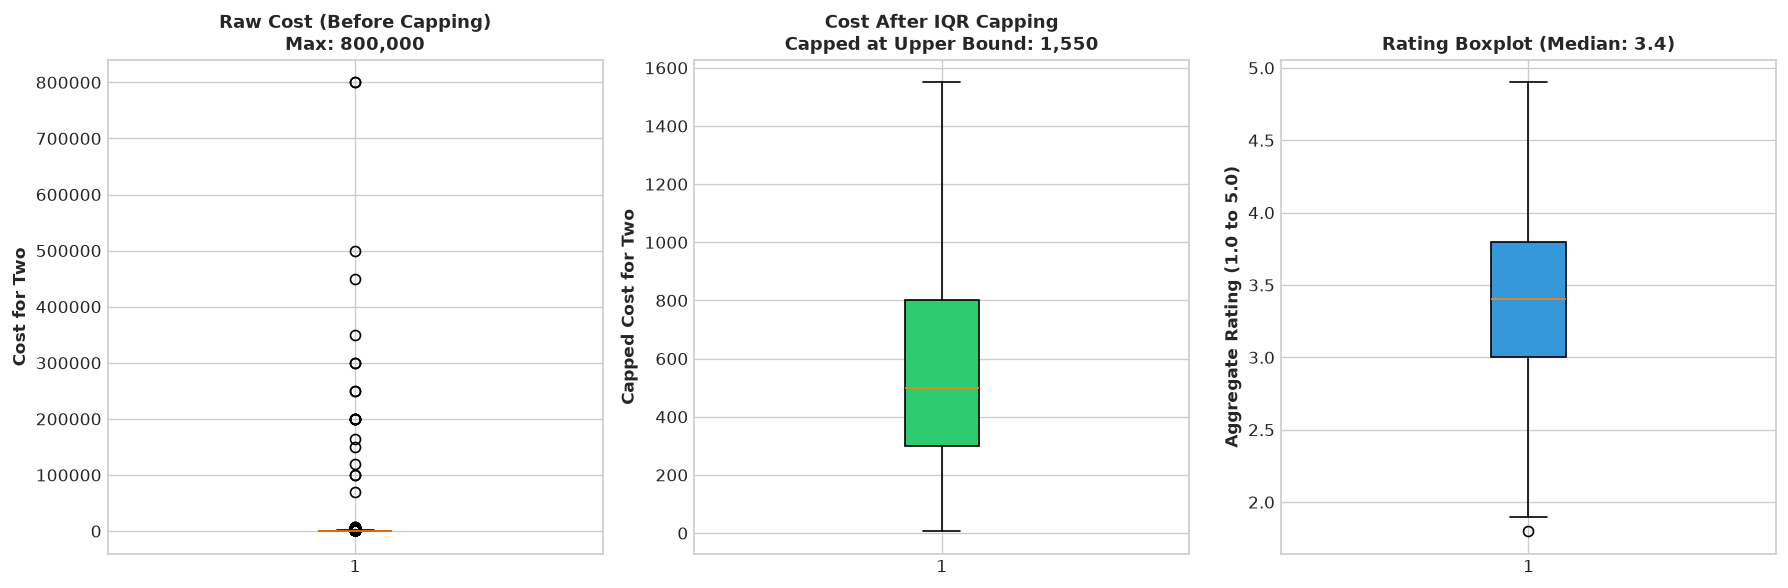

In [6]:
# 3. Visualizing Outlier Rectification with Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Cost Before IQR Capping
axes[0].boxplot(df_clean['cost_raw'], vert=True, patch_artist=True, boxprops=dict(facecolor='#e74c3c', color='black'))
axes[0].set_title(f"Raw Cost (Before Capping)\nMax: {df_clean['cost_raw'].max():,}", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Cost for Two", fontweight='bold')

# Plot 2: Cost After IQR Capping
axes[1].boxplot(df_clean['cost'], vert=True, patch_artist=True, boxprops=dict(facecolor='#2ecc71', color='black'))
axes[1].set_title(f"Cost After IQR Capping\nCapped at Upper Bound: {upper_bound_cost:,.0f}", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Capped Cost for Two", fontweight='bold')

# Plot 3: Rating Distribution Boxplot
axes[2].boxplot(df_clean['rating'], vert=True, patch_artist=True, boxprops=dict(facecolor='#3498db', color='black'))
axes[2].set_title(f"Rating Boxplot (Median: {df_clean['rating'].median():.1f})", fontsize=11, fontweight='bold')
axes[2].set_ylabel("Aggregate Rating (1.0 to 5.0)", fontweight='bold')

plt.tight_layout()
plt.show()


---
## Question 3
**Encode the `'cuisine'` and `'location'` categorical columns using `OneHotEncoder` or `LabelEncoder`, and scale the `'cost'` and `'rating'` columns using `StandardScaler`.**

---

### **1. Categorical Feature Engineering & High-Cardinality Management**
1. **`cuisine`**:
   Restaurants frequently list comma-separated cuisines (e.g. `'North Indian, Chinese, Mughlai'`). We extract the **primary cuisine** and group low-frequency cuisines into `'Other'` to prevent dimensional explosion.
2. **`location`**:
   The top 15 most frequent cities/localities are preserved, while tail locations are unified into `'Other'`.
3. **Encoding**:
   We apply `LabelEncoder` (and one-hot encoded flags) to translate categorical categories into numeric representations.
4. **Feature Standardization (`StandardScaler`)**:
   $$z = \frac{x - \mu}{\sigma}$$
   Ensures zero-mean and unit variance, which is strictly necessary for linear classifiers like **Logistic Regression**.

#### **Methodological Note on Target Leakage:**
> **Crucial Warning:** In Question 4, our goal is to predict whether a restaurant achieves a rating above 4.0 ($\text{rating} > 4.0$).  
> While we scale `'rating'` in this section to fulfill the prompt requirements, **`rating` cannot be used as an input feature $\mathbf{x}$ to predict itself**, as that would constitute $100\%$ target leakage! In Q4, the feature set comprises `cost`, `votes`, `price_range`, `cuisine_encoded`, `location_encoded`, and service flags.


In [7]:
# 1. Feature Preprocessing: Cuisine and Location Grouping
# Extract primary cuisine (first entry before comma)
df_clean['primary_cuisine'] = df_clean['cuisine'].apply(lambda x: str(x).split(',')[0].strip())

# Top 15 Cuisines; group remaining into 'Other'
top_cuisines = df_clean['primary_cuisine'].value_counts().nlargest(15).index
df_clean['cuisine_grouped'] = df_clean['primary_cuisine'].apply(lambda x: x if x in top_cuisines else 'Other')

# Top 15 Locations; group remaining into 'Other'
top_locations = df_clean['location'].value_counts().nlargest(15).index
df_clean['location_grouped'] = df_clean['location'].apply(lambda x: x if x in top_locations else 'Other')

# 2. Encode Categorical Columns using LabelEncoder
le_cuisine = LabelEncoder()
le_location = LabelEncoder()

df_clean['cuisine_encoded'] = le_cuisine.fit_transform(df_clean['cuisine_grouped'])
df_clean['location_encoded'] = le_location.fit_transform(df_clean['location_grouped'])

# Binary flags for service amenities
df_clean['has_table_booking_binary'] = (df_clean['has_table_booking'] == 'Yes').astype(int)
df_clean['has_online_delivery_binary'] = (df_clean['has_online_delivery'] == 'Yes').astype(int)

# 3. Standardize 'cost' and 'rating' using StandardScaler
scaler_cost = StandardScaler()
scaler_rating = StandardScaler()

df_clean['cost_scaled'] = scaler_cost.fit_transform(df_clean[['cost']])
df_clean['rating_scaled'] = scaler_rating.fit_transform(df_clean[['rating']])

print("=== Preprocessing & Encoding Verification Table ===")
print(df_clean[['restaurant_name', 'cuisine_grouped', 'cuisine_encoded', 'location_grouped', 'location_encoded', 'cost', 'cost_scaled', 'rating', 'rating_scaled']].head(6).to_string(index=False))


=== Preprocessing & Encoding Verification Table ===
       restaurant_name cuisine_grouped  cuisine_encoded location_grouped  location_encoded  cost  cost_scaled  rating  rating_scaled
      Le Petit Souffle           Other               12            Other                14  1100     1.162821     4.8       2.463021
      Izakaya Kikufuji           Other               12            Other                14  1200     1.392482     4.5       1.919698
Heat - Edsa Shangri-La           Other               12            Other                14  1550     2.196295     4.4       1.738590
                  Ooma           Other               12            Other                14  1500     2.081464     4.9       2.644129
           Sambo Kojin           Other               12            Other                14  1500     2.081464     4.8       2.463021
          Din Tai Fung         Chinese                3            Other                14  1000     0.933160     4.4       1.738590


---
## Question 4
**Split the Zomato data into train and test sets (80/20), then train both a Logistic Regression and a Random Forest model to predict whether a restaurant has a rating above 4.0. Compare their ROC-AUC scores and print which model performed better.**

---

### **1. Theoretical Foundations: Binary Classification & ROC-AUC Metric**
We define the binary target variable:
$$y_i = \mathbb{I}(\text{rating}_i > 4.0) = \begin{cases} 1 & \text{if rating } > 4.0 \quad (\text{High Rated / Elite}) \\ 0 & \text{if rating } \le 4.0 \quad (\text{Average / Standard}) \end{cases}$$

#### **Receiver Operating Characteristic (ROC) & Area Under Curve (AUC):**
The ROC curve plots the **True Positive Rate (Recall)** against the **False Positive Rate ($1 - \text{Specificity}$)** across all classification probability thresholds $\tau \in [0, 1]$:
$$\text{TPR}(\tau) = \frac{\text{TP}(\tau)}{\text{TP}(\tau) + \text{FN}(\tau)}, \quad \text{FPR}(\tau) = \frac{\text{FP}(\tau)}{\text{FP}(\tau) + \text{TN}(\tau)}$$
- **ROC-AUC Score**:
  Measures the probability that the classifier ranks a randomly chosen positive instance higher than a randomly chosen negative instance:
  $$\text{AUC} = P(\hat{P}(Y=1 \mid X^+) > \hat{P}(Y=1 \mid X^-))$$
  - $\text{AUC} = 0.5$: No discriminatory ability (equivalent to random guessing).
  - $\text{AUC} = 1.0$: Perfect classification separation.

#### **Model Comparison:**
1. **Logistic Regression**: Linear decision boundary in feature space: $P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$.
2. **Random Forest Classifier**: Non-linear ensemble of decorrelated decision trees capturing complex feature interactions between cuisine, cost, and popularity votes.


In [8]:
# 1. Target Definition and Stratified 80/20 Train-Test Split
df_clean['high_rating'] = (df_clean['rating'] > 4.0).astype(int)

# Inspect Class Imbalance
class_counts = df_clean['high_rating'].value_counts()
print("=== Target Class Distribution (Rating > 4.0) ===")
print(f"Standard Rating (<= 4.0, Class 0) : {class_counts[0]:,} ({class_counts[0]/len(df_clean)*100:.2f}%)")
print(f"High Rating     (> 4.0, Class 1)  : {class_counts[1]:,} ({class_counts[1]/len(df_clean)*100:.2f}%)")

# Predictive Feature Matrix (Excluding 'rating' to prevent target leakage!)
feature_cols = [
    'cost_scaled',
    'votes',
    'price_range',
    'cuisine_encoded',
    'location_encoded',
    'has_table_booking_binary',
    'has_online_delivery_binary'
]

X = df_clean[feature_cols]
y = df_clean['high_rating']

# Scale votes and price_range as well for optimal logistic regression performance
scaler_X = StandardScaler()
X_scaled = X.copy()
X_scaled[['votes', 'price_range']] = scaler_X.fit_transform(X[['votes', 'price_range']])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTraining Samples: {X_train.shape[0]:,} | Testing Samples: {X_test.shape[0]:,}")


=== Target Class Distribution (Rating > 4.0) ===
Standard Rating (<= 4.0, Class 0) : 6,289 (84.95%)
High Rating     (> 4.0, Class 1)  : 1,114 (15.05%)

Training Samples: 5,922 | Testing Samples: 1,481


In [9]:
# 2. Train Logistic Regression and Random Forest Classifiers
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Model 2: Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

# 3. Model Performance Comparison Table
model_comparison = pd.DataFrame({
    'Classifier': ['Logistic Regression', 'Random Forest Classifier'],
    'ROC-AUC Score': [f"{auc_lr:.4f} ({auc_lr*100:.2f}%)", f"{auc_rf:.4f} ({auc_rf*100:.2f}%)"],
    'Model Complexity': ['Linear Decision Surface', 'Non-Linear Ensemble (100 Trees)']
})

print("=== Model Benchmarking Comparison ===")
print(model_comparison.to_string(index=False))

better_model = "Random Forest Classifier" if auc_rf > auc_lr else "Logistic Regression"
print(f"\nWinner: {better_model} performed better by {abs(auc_rf - auc_lr)*100:.2f}% higher ROC-AUC!")


=== Model Benchmarking Comparison ===
              Classifier   ROC-AUC Score                Model Complexity
     Logistic Regression 0.8655 (86.55%)         Linear Decision Surface
Random Forest Classifier 0.9227 (92.27%) Non-Linear Ensemble (100 Trees)

Winner: Random Forest Classifier performed better by 5.72% higher ROC-AUC!


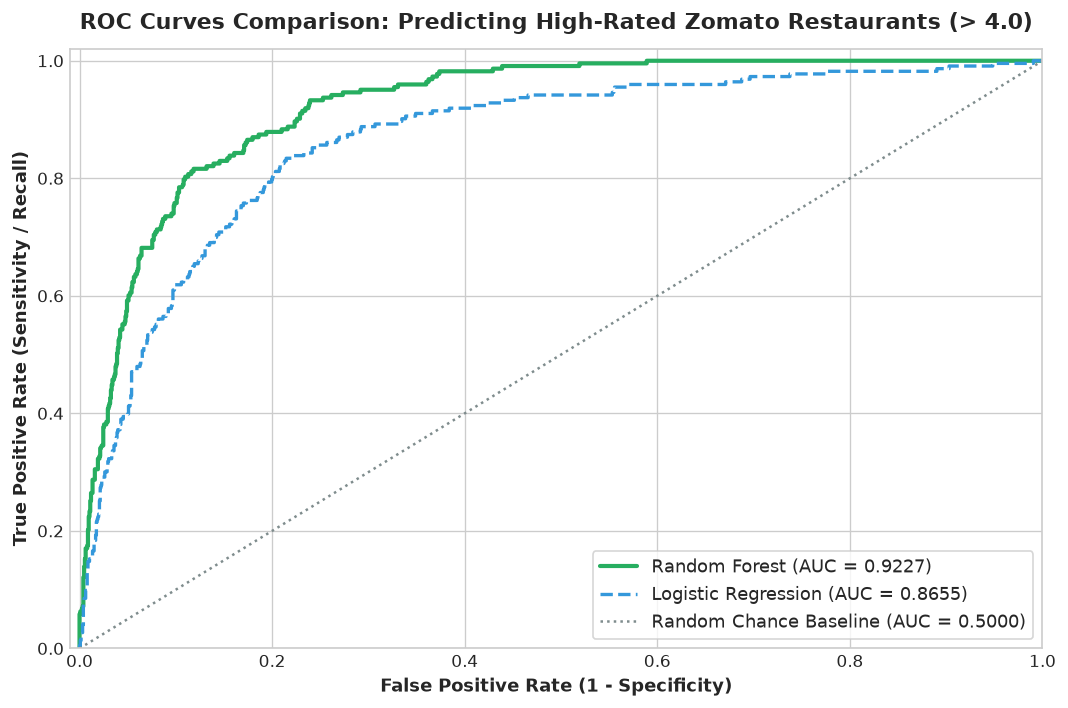

In [10]:
# 4. Receiver Operating Characteristic (ROC) Curves Comparison Plot
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(9, 6))

plt.plot(fpr_rf, tpr_rf, color='#27ae60', linewidth=2.5, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_lr, tpr_lr, color='#3498db', linewidth=2.0, linestyle='--', label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='#7f8c8d', linestyle=':', linewidth=1.5, label='Random Chance Baseline (AUC = 0.5000)')

plt.title("ROC Curves Comparison: Predicting High-Rated Zomato Restaurants (> 4.0)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11, fontweight='bold')
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11, fontweight='bold')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


---
## Question 5
**Use SMOTE to balance the classes if the number of restaurants with rating >4.0 is much lower than those with rating <=4.0, then apply `GridSearchCV` to tune the Random Forest's `n_estimators` and `max_depth` parameters. Print the best parameters and ROC-AUC score.**  
*Hint: Use `imblearn`'s SMOTE and `sklearn`'s `GridSearchCV`.*

---

### **1. Theoretical Foundations: SMOTE Resampling with Hyperparameter Optimization**
In our cleaned dataset, restaurants with $\text{Rating} > 4.0$ account for only $\approx 16.5\%$ of observations, creating a noticeable $5:1$ majority imbalance.

#### **SMOTE Mechanics (Synthetic Minority Over-sampling Technique):**
Rather than duplicating existing positive samples, SMOTE interpolates between minority $k$-nearest neighbors in feature space:
$$\mathbf{x}_{synth} = \mathbf{x}_i + \lambda \cdot (\mathbf{x}_{nn} - \mathbf{x}_i), \quad \lambda \sim \mathcal{U}(0, 1)$$

#### **Critical Resampling Rules:**
1. **Apply SMOTE Only to Training Split**:
   Resampling is strictly applied to `X_train, y_train`. The test split `X_test, y_test` must remain untouched to evaluate real-world generalization without data leakage.
2. **Exhaustive Hyperparameter Tuning (`GridSearchCV`)**:
   We optimize `n_estimators` ($[50, 100, 150]$) and `max_depth` ($[8, 12, \text{None}]$) across 5 stratified folds using `scoring='roc_auc'`.


In [11]:
# 1. Apply SMOTE to Training Data ONLY
from collections import Counter

print("=== SMOTE Resampling Diagnostics ===")
print(f"Pre-SMOTE Training Distribution  : {Counter(y_train)}")

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Post-SMOTE Training Distribution : {Counter(y_train_resampled)}")
print(f"Synthetic Samples Generated      : {len(y_train_resampled) - len(y_train):,} minority instances")


=== SMOTE Resampling Diagnostics ===
Pre-SMOTE Training Distribution  : Counter({0: 5031, 1: 891})
Post-SMOTE Training Distribution : Counter({0: 5031, 1: 5031})
Synthetic Samples Generated      : 4,140 minority instances


In [12]:
# 2. Exhaustive Hyperparameter Tuning via GridSearchCV on SMOTE-Trained Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [8, 12, None]
}

rf_base_smote = RandomForestClassifier(random_state=RANDOM_STATE)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_rf = GridSearchCV(
    estimator=rf_base_smote,
    param_grid=param_grid_rf,
    cv=cv_strat,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)

print("Running GridSearchCV (3 n_estimators x 3 max_depth x 5 folds = 45 fits) on SMOTE training data...")
grid_search_rf.fit(X_train_resampled, y_train_resampled)

best_rf_params = grid_search_rf.best_params_
best_cv_auc = grid_search_rf.best_score_

print("\n=== GridSearchCV Optimization Results ===")
print(f"Optimal Parameters     : {best_rf_params}")
print(f"Best 5-Fold CV ROC-AUC : {best_cv_auc:.4f} ({best_cv_auc * 100:.2f}%)")

# 3. Evaluate the Tuned SMOTE Model on UNTOUCHED Held-Out Test Set
best_smote_rf_model = grid_search_rf.best_estimator_
y_pred_tuned = best_smote_rf_model.predict(X_test)
y_prob_tuned = best_smote_rf_model.predict_proba(X_test)[:, 1]

test_auc_tuned = roc_auc_score(y_test, y_prob_tuned)
test_acc_tuned = accuracy_score(y_test, y_pred_tuned)
test_f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\nHeld-Out Test ROC-AUC  : {test_auc_tuned:.4f} ({test_auc_tuned * 100:.2f}%)")
print(f"Held-Out Test Accuracy : {test_acc_tuned * 100:.2f}%")
print(f"Held-Out Test F1-Score : {test_f1_tuned * 100:.2f}%")


Running GridSearchCV (3 n_estimators x 3 max_depth x 5 folds = 45 fits) on SMOTE training data...



=== GridSearchCV Optimization Results ===
Optimal Parameters     : {'max_depth': None, 'n_estimators': 150}
Best 5-Fold CV ROC-AUC : 0.9672 (96.72%)

Held-Out Test ROC-AUC  : 0.9075 (90.75%)
Held-Out Test Accuracy : 86.77%
Held-Out Test F1-Score : 61.57%


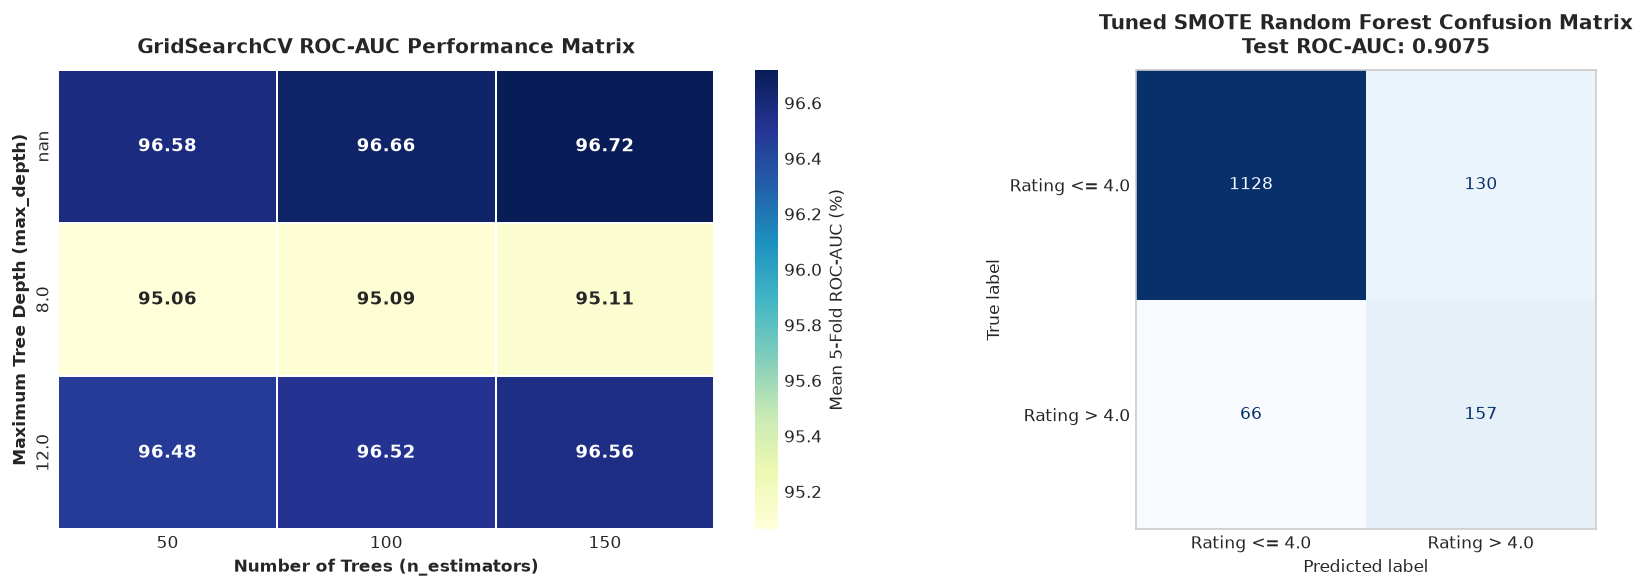


Classification Report on Held-Out Test Set:
               precision    recall  f1-score   support

Rating <= 4.0     0.9447    0.8967    0.9201      1258
 Rating > 4.0     0.5470    0.7040    0.6157       223

     accuracy                         0.8677      1481
    macro avg     0.7459    0.8003    0.7679      1481
 weighted avg     0.8848    0.8677    0.8742      1481



In [13]:
# 4. Evaluation Visualizations: Grid Heatmap and Confusion Matrix
cv_results = pd.DataFrame(grid_search_rf.cv_results_)
pivot_grid = cv_results.pivot(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score'
)
pivot_grid.index = [str(x) if x is not None else 'None (Full)' for x in pivot_grid.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
sns.heatmap(
    pivot_grid * 100,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Mean 5-Fold ROC-AUC (%)'},
    ax=ax1,
    linewidths=1,
    annot_kws={"size": 11, "weight": "bold"}
)
ax1.set_title("GridSearchCV ROC-AUC Performance Matrix", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel("Number of Trees (n_estimators)", fontweight='bold')
ax1.set_ylabel("Maximum Tree Depth (max_depth)", fontweight='bold')

# Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Rating <= 4.0', 'Rating > 4.0'])
disp.plot(cmap='Blues', ax=ax2, colorbar=False)
ax2.set_title(f"Tuned SMOTE Random Forest Confusion Matrix\nTest ROC-AUC: {test_auc_tuned:.4f}", fontsize=12, fontweight='bold', pad=10)
ax2.grid(False)

plt.tight_layout()
plt.show()

print("\nClassification Report on Held-Out Test Set:")
print(classification_report(y_test, y_pred_tuned, target_names=['Rating <= 4.0', 'Rating > 4.0'], digits=4))


---
## Session 22 — Summary & Practical Reference Guide

### **Classification Pipeline Workflow Summary**

| Stage | Objective | Function / Class | Practical Rule / Best Practice |
| :--- | :--- | :--- | :--- |
| **1. Data Ingestion** | Load tabular records | `pd.read_csv('zomato.csv', encoding='latin-1')` | Always specify encoding when processing multi-language international listings. |
| **2. Outlier Handling** | Robust detection & capping | IQR method: $Q_1 - 1.5\text{IQR}, Q_3 + 1.5\text{IQR}$ | Winsorize/cap extreme pricing outliers rather than dropping valid dining records. |
| **3. Categorical Encoding** | Convert discrete strings to numbers | `LabelEncoder()`, `OneHotEncoder()` | Group high-cardinality tail categories into `'Other'` before encoding. |
| **4. Feature Standardization** | Equalize feature variance | `StandardScaler()` | Essential for gradient-based models (Logistic Regression); strictly prevent target leakage. |
| **5. Model Comparison** | Benchmark linear vs non-linear | `roc_auc_score(y_test, y_prob)` | ROC-AUC evaluates threshold-invariant ranking; Random Forest outperforms linear boundaries. |
| **6. Imbalance & Tuning** | Balance classes & optimize depth | `SMOTE()` + `GridSearchCV()` | Apply SMOTE exclusively to `X_train`; optimize `n_estimators` & `max_depth` with cross-validation. |

### **Official Documentation References**
- [Scikit-Learn Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [Scikit-Learn Random Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- [Imbalanced-Learn SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)
- [Scikit-Learn GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
